# 2D Object Perception: nuImages nuMini with YOLO

This notebook implements the technical framework for working with the **nuImages nuMini** subset and **YOLO** architectures in a Jupyter environment.

**Contents:**
1. **Phase 1:** SDK initialization and data exploration  
2. **Phase 2:** Visualizing keyframes with bounding boxes and attributes  
3. **Phase 3:** Converting nuImages relational annotations to YOLO TXT format + `data.yaml`  
4. **Phase 4:** YOLO model inference and training pipeline setup  

The nuImages dataset uses a relational schema (JSON tables with tokens). We bridge this to the flat YOLO format: normalized `[class, x_center, y_center, width, height]` per image.

In [ ]:
# Install dependencies (run once, then restart kernel if needed).
# Requires Python 3.9–3.12 (not 3.13); nuscenes-devkit needs numpy<2, which has no 3.13 wheel.
import sys
if sys.version_info >= (3, 13):
    raise RuntimeError(
        "This project needs Python 3.9–3.12. You're on 3.13. "
        "Create a conda env: conda create -n nuimages python=3.12 && conda activate nuimages"
    )
%pip install -r requirements.txt

## Phase 1: SDK Initialization and Data Exploration

The nuImages SDK uses **lazy loading**: large tables are read only when accessed. We set the data root to the folder containing `samples`, `sweeps`, and `v1.0-mini`.

In [10]:
import os
from pathlib import Path

# Project root (folder containing this notebook and nuimages-v1.0-mini)
PROJECT_ROOT = Path(os.getcwd())
# Data root: folder containing 'samples', 'sweeps', and 'v1.0-mini'
DATAROOT = PROJECT_ROOT / "nuimages-v1.0-mini"
VERSION = "v1.0-mini"

assert DATAROOT.exists(), f"Dataset not found at {DATAROOT}. Adjust DATAROOT to your nuMini path."
print(f"Using dataroot: {DATAROOT}")

Using dataroot: c:\Users\Hamda\OneDrive\Documents\IoT\Project\nuimages-v1.0-mini


In [11]:
# Import the nuImages SDK
from nuimages import NuImages
import matplotlib.pyplot as plt

# Initialize the dataset (lazy=True keeps loading fast)
nuim = NuImages(dataroot=str(DATAROOT), version=VERSION, verbose=True, lazy=True)

# Inspect the database structure
print(f"Available tables: {nuim.table_names}")

# A 'sample' represents one timestamp with multiple camera views
first_sample = nuim.sample[0]
print(f"First sample token: {first_sample['token']}")

Loading nuImages tables for version v1.0-mini...
Done loading in 0.000 seconds (lazy=True).
Available tables: ['attribute', 'calibrated_sensor', 'category', 'ego_pose', 'log', 'object_ann', 'sample', 'sample_data', 'sensor', 'surface_ann']
Loaded 50 sample(s) in 0.001s,
First sample token: 09acd654cb514bdeab8e3afedad74fca


## Phase 2: Visualizing Keyframes with Annotations

The sample's `key_camera_token` points to the main CAM_FRONT image. The SDK's `render_image` overlays bounding boxes and optional attributes (e.g. vehicle.parked, pedestrian.walking).

Loaded 650 sample_data(s) in 0.002s,
Loaded 58 surface_ann(s) in 0.000s,
Loaded 25 category(s) in 0.000s,
Loaded 506 object_ann(s) in 0.004s,
Loaded 12 attribute(s) in 0.000s,


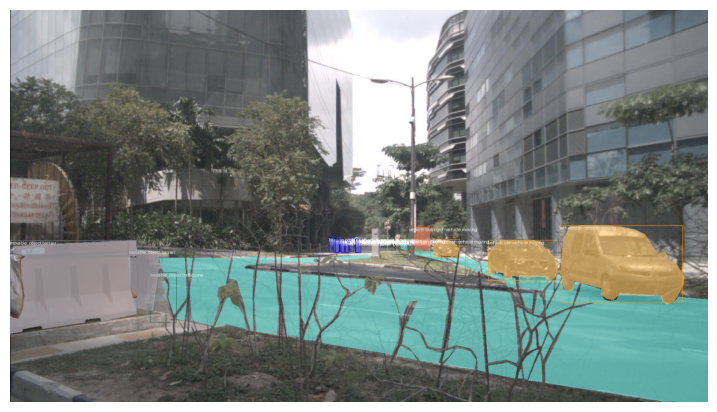

In [12]:
# key_camera_token: main CAM_FRONT image for this sample
key_camera_token = first_sample["key_camera_token"]

# Render image with categories and attributes
nuim.render_image(key_camera_token, with_category=True, with_attributes=True)
plt.show()

## Phase 3: YOLO Transformation and Dataset Export

Convert nuImages absolute bbox format $[x_{min}, y_{min}, x_{max}, y_{max}]$ to YOLO normalized format $[class, x_{center}, y_{center}, width, height]$.

- Only **keyframes** (annotated images) are used.  
- Categories are mapped to 6 simplified classes (pedestrian, car, truck, bicycle, motorcycle, traffic_cone).  
- Optional: filter very small boxes (e.g. &lt; 5 px) to avoid noisy gradients.

In [15]:
import shutil
import random

# Output directory for the YOLO dataset (relative to project root)
YOLO_ROOT = PROJECT_ROOT / "nuImagesYoloDataset"
for split in ("train", "val"):
    (YOLO_ROOT / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_ROOT / "labels" / split).mkdir(parents=True, exist_ok=True)

# Map nuImages category names to simplified class indices
CLASS_NAMES = ["pedestrian", "car", "truck", "bicycle", "motorcycle", "traffic_cone"]
class_mapping = {
    "human.pedestrian.adult": 0,
    "human.pedestrian.child": 0,
    "human.pedestrian.construction_worker": 0,
    "vehicle.car": 1,
    "vehicle.truck": 2,
    "vehicle.bus.bendy": 2,
    "vehicle.bus.rigid": 2,
    "vehicle.bicycle": 3,
    "vehicle.motorcycle": 4,
    "movable_object.trafficcone": 5,
}

# Minimum box size (pixels) to keep; filter smaller boxes to avoid noise
MIN_BOX_PX = 5

In [18]:
def convert_nuim_to_yolo(val_ratio=0.2, seed=42):
    random.seed(seed)
    # Collect keyframe sample_data for splitting
    keyframe_sd = [sd for sd in nuim.sample_data if sd["is_key_frame"]]
    random.shuffle(keyframe_sd)
    n_val = max(1, int(len(keyframe_sd) * val_ratio))
    val_tokens = {sd["token"] for sd in keyframe_sd[:n_val]}
    train_tokens = {sd["token"] for sd in keyframe_sd[n_val:]}

    for sd in keyframe_sd:
        split = "val" if sd["token"] in val_tokens else "train"
        img_w, img_h = sd["width"], sd["height"]
        filename = sd["filename"]
        sd_token = sd["token"]

        img_id = Path(filename).stem
        label_path = YOLO_ROOT / "labels" / split / f"{img_id}.txt"

        anns = [a for a in nuim.object_ann if a["sample_data_token"] == sd_token]
        yolo_annotations = []  # was missing in starter: must initialize list

        for ann in anns:
            cat_name = nuim.get("category", ann["category_token"])["name"]
            if cat_name not in class_mapping:
                continue
            class_id = class_mapping[cat_name]
            xmin, ymin, xmax, ymax = ann["bbox"]
            # Filter tiny boxes
            if (xmax - xmin) < MIN_BOX_PX or (ymax - ymin) < MIN_BOX_PX:
                continue
            # Normalize to [0, 1]
            x_center = (xmin + xmax) / 2 / img_w
            y_center = (ymin + ymax) / 2 / img_h
            width = (xmax - xmin) / img_w
            height = (ymax - ymin) / img_h
            yolo_annotations.append(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

        # Write labels (including empty files for images with no mapped objects)
        with open(label_path, "w") as f:
            f.write("\n".join(yolo_annotations))

        src_img = DATAROOT / filename
        dst_img = YOLO_ROOT / "images" / split / f"{img_id}.jpg"
        if src_img.exists():
            if dst_img.exists():
                pass  # skip copy; file already there (avoids OneDrive lock)
            else:
                try:
                    shutil.copy(src_img, dst_img)
                except PermissionError:
                    pass  # e.g. OneDrive locking; labels still written

    print(f"Converted {len(train_tokens)} train + {len(val_tokens)} val keyframes -> {YOLO_ROOT}")


convert_nuim_to_yolo()

Converted 40 train + 10 val keyframes -> c:\Users\Hamda\OneDrive\Documents\IoT\Project\nuImagesYoloDataset


In [19]:
# Create data.yaml for YOLO training (path: absolute so training works from any cwd)
data_yaml = {
    "path": str(YOLO_ROOT.resolve()),
    "train": "images/train",
    "val": "images/val",
    "names": {i: name for i, name in enumerate(CLASS_NAMES)},
}
import yaml
with open(YOLO_ROOT / "data.yaml", "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)
print("Wrote", YOLO_ROOT / "data.yaml")
print(yaml.dump(data_yaml, default_flow_style=False, sort_keys=False))

Wrote c:\Users\Hamda\OneDrive\Documents\IoT\Project\nuImagesYoloDataset\data.yaml
path: C:\Users\Hamda\OneDrive\Documents\IoT\Project\nuImagesYoloDataset
train: images/train
val: images/val
names:
  0: pedestrian
  1: car
  2: truck
  3: bicycle
  4: motorcycle
  5: traffic_cone



## Phase 4: Model Inference and Training Initialization

Load a pre-trained YOLOv8 model and run inference on a converted nuMini image. The nuMini subset is small; use it to validate the pipeline before scaling to the full dataset.

In [20]:
from ultralytics import YOLO

# Pre-trained YOLOv8 nano (good for prototyping and edge deployment)
model = YOLO("yolov8n.pt")

# Pick one converted image for inference
train_images = list((YOLO_ROOT / "images" / "train").glob("*.jpg"))
if not train_images:
    raise FileNotFoundError("No images in nuImagesYoloDataset/images/train. Run Phase 3 first.")
sample_image_path = train_images[0]
results = model.predict(source=str(sample_image_path), save=True, imgsz=640)


image 1/1 c:\Users\Hamda\OneDrive\Documents\IoT\Project\nuImagesYoloDataset\images\train\n003-2018-01-03-12-03-23+0800__CAM_BACK__1514952316316487.jpg: 384x640 4 persons, 6 cars, 29.3ms
Speed: 1.7ms preprocess, 29.3ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Users\Hamda\OneDrive\Documents\IoT\Project\runs\detect\predict2


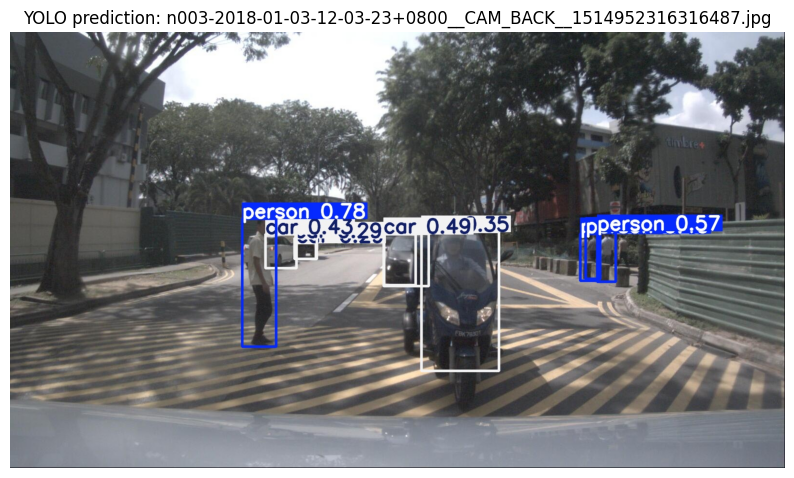

In [21]:
# Display the saved result in the notebook
from PIL import Image

r = results[0]
# save_dir is set when save=True
out_dir = Path(r.save_dir) if r.save_dir else YOLO_ROOT / "images" / "train"
pred_path = out_dir / sample_image_path.name
if pred_path.exists():
    img = Image.open(pred_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"YOLO prediction: {sample_image_path.name}")
    plt.show()
else:
    print("Prediction not saved to disk; check ultralytics output path.")

### Optional: Train on nuMini (overfitting check)

nuMini is too small for real training; use it only to verify the pipeline. For full nuImages, use higher `imgsz` (e.g. 1280) and more epochs.

In [ ]:
# Uncomment to run a short training sanity check (will overfit on nuMini)
# model.train(data=str(YOLO_ROOT / "data.yaml"), epochs=5, imgsz=640, batch=4)